In [4]:
pip install --upgrade matplotlib-map-utils

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
print(sys.version)

3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]


In [6]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import os
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import geopandas as gpd
import charset_normalizer
from matplotlib_map_utils import north_arrow

In [7]:
print(matplotlib.__version__)

3.10.7


In [8]:
path = "/home/harris/Downloads/Shasee/Assignment 8/GWDBDownload/GWDBDownload"
os.chdir(path)

In [9]:
fname = 'WellMain.txt'
watqual = 'WaterQualityMajor.txt'
bndfile = 'Hardin.gpkg'
res1 = charset_normalizer.from_path(fname).best()
res2 = charset_normalizer.from_path(watqual).best()
print('WellMain.txt Encoding:', (res1.encoding), 'and', 'WaterQualityMajor.txt Encoding:', (res2.encoding))

WellMain.txt Encoding: cp1250 and WaterQualityMajor.txt Encoding: ascii


In [10]:
wells = pd.read_csv(fname, sep = '|', encoding = 'cp1250', dtype = 'str')
wells.head()

,StateWellNumber,County,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer,...,WellReportTrackingNumber,PluggingReportTrackingNumber,USGSSiteNumber,TCEQSourceId,GCDWellNumber,OwnerWellNumber,OtherWellNumber,PreviousStateWellNumber,CreatedDate,LastUpdateDate
0,0140301,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2004-05-18,2025-05-13
1,0140302,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2003-12-23,2022-12-02
2,0140601,Dallam,Canadian,1,A - Panhandle,North Plains GCD,211DKOP,Dakota Group and Purgatoire Formation,23,Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-01,2020-01-16
3,0140901,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLL,Ogallala Formation,21,Ogallala,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1966-08-30,2018-03-27
4,0140902,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLD,Ogallala Formation and Dakota Group,58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-10-01,2020-01-16


In [11]:
wells.columns

Index(['StateWellNumber', 'County', 'RiverBasin', 'GMA', 'RWPA', 'GCD',
       'AquiferCode', 'AquiferCodeDescription', 'AquiferId', 'Aquifer',
       'Classification', 'AquiferPickMethod', 'LatitudeDD', 'Dlat', 'Mlat',
       'Slat', 'LongitudeDD', 'Dlong', 'Mlong', 'Slong', 'CoordinateSource',
       'Owner', 'Driller', 'WellDepth', 'DepthSource', 'LandSurfaceElevation',
       'LandSurfaceElevationMethod', 'DrillingStartDate', 'DrillingMonth',
       'DrillingDay', 'DrillingYear', 'DrillingEndDate', 'DrillingMethod',
       'BoreHoleCompletion', 'WellType', 'Pump', 'PowerType', 'WellUse',
       'WaterLevelStatus', 'CurrentWaterLevelWell', 'WaterQualityAvailable',
       'CurrentWaterQualityWell', 'ReportingAgency', 'OtherDataAvailable',
       'Remarks', 'WellReportTrackingNumber', 'PluggingReportTrackingNumber',
       'USGSSiteNumber', 'TCEQSourceId', 'GCDWellNumber', 'OwnerWellNumber',
       'OtherWellNumber', 'PreviousStateWellNumber', 'CreatedDate',
       'LastUpdateDate'],


In [12]:
watquality = pd.read_csv(watqual, sep = '|', encoding = 'ascii', dtype = 'str')
watquality.head()

,StateWellNumber,County,Aquifer,SampleMonth,SampleDay,SampleYear,SampleDate,SampleTime,SampleTimeZone,SampleNumber,...,SampleBU,SampleBUValue,ParameterCode,ParameterDescription,ParameterUnitOfMeasure,ParameterFlag,ParameterValue,ParameterValuePlusMinus,CreatedDate,LastUpdateDate
0,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,39086,ALKALINITY FIELD DISSOLVED AS CACO3,MG/L AS CACO3,NaN,186,NaN,NaN,NaN
1,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00415,"ALKALINITY, PHENOLPHTHALEIN (MG/L)",mg/L,NaN,0,NaN,2016-04-28,NaN
2,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00410,"ALKALINITY, TOTAL (MG/L AS CACO3)",MG/L AS CACO3,NaN,188,NaN,2016-04-28,NaN
3,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01503,"ALPHA, DISSOLVED (PC/L)",PC/L,NaN,6.4000000000000004,2.6000000000000001,NaN,NaN
4,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01000,"ARSENIC, DISSOLVED (UG/L AS AS)",ug/L,<,10,NaN,NaN,NaN


In [13]:
watquality.columns

Index(['StateWellNumber', 'County', 'Aquifer', 'SampleMonth', 'SampleDay',
       'SampleYear', 'SampleDate', 'SampleTime', 'SampleTimeZone',
       'SampleNumber', 'Reliability', 'CollectionEntity', 'AnalyzedLab',
       'SampledAquifer', 'SampleTopInterval', 'SampleBottomInterval',
       'CollectionRemarks', 'SampleBU', 'SampleBUValue', 'ParameterCode',
       'ParameterDescription', 'ParameterUnitOfMeasure', 'ParameterFlag',
       'ParameterValue', 'ParameterValuePlusMinus', 'CreatedDate',
       'LastUpdateDate'],
      dtype='object')

In [14]:
watqualitya = watquality[['StateWellNumber','County', 'Aquifer','ParameterCode', 'ParameterValue', 'ParameterUnitOfMeasure']]
watqualitya

,StateWellNumber,County,Aquifer,ParameterCode,ParameterValue,ParameterUnitOfMeasure
0,0148904,Dallam,Ogallala,39086,186,MG/L AS CACO3
1,0148904,Dallam,Ogallala,00415,0,mg/L
2,0148904,Dallam,Ogallala,00410,188,MG/L AS CACO3
3,0148904,Dallam,Ogallala,01503,6.4000000000000004,PC/L
4,0148904,Dallam,Ogallala,01000,10,ug/L
...,...,...,...,...,...,...
2227137,8905404,Cameron,Gulf Coast,00932,81,PCT
2227138,8905404,Cameron,Gulf Coast,00929,1280,mg/L
2227139,8905404,Cameron,Gulf Coast,00094,8160,MICR
2227140,8905404,Cameron,Gulf Coast,00945,1929,MG/L AS SO4


In [15]:
ECHar = watqualitya.loc[(watqualitya['County'] == 'Hardin') & (watqualitya['ParameterCode'] == '00094'), ['StateWellNumber','ParameterCode', 'ParameterValue']]
ECHar.head()

,StateWellNumber,ParameterCode,ParameterValue
1465477,6129803,00094,410
1465517,6129803,00094,360
1465562,6129803,00094,355
1465609,6129803,00094,332
1465654,6129803,00094,311


In [16]:
wellsHard = wells.loc[(wells['County'] == 'Hardin'), ['StateWellNumber','LatitudeDD', 'LongitudeDD']]
wellsHard.head()

,StateWellNumber,LatitudeDD,LongitudeDD
104111,6129701,30.5172220,-94.4683330
104112,6129702,30.5147230,-94.4619450
104118,6129801,30.5061120,-94.4541670
104119,6129802,30.5036120,-94.4236110
104120,6129803,30.5119450,-94.4477780


In [17]:
EChard2 = ECHar.merge(wellsHard, on ='StateWellNumber', how = 'inner')
EChard2

,StateWellNumber,ParameterCode,ParameterValue,LatitudeDD,LongitudeDD
0,6129803,00094,410,30.5119450,-94.4477780
1,6129803,00094,360,30.5119450,-94.4477780
2,6129803,00094,355,30.5119450,-94.4477780
3,6129803,00094,332,30.5119450,-94.4477780
4,6129803,00094,311,30.5119450,-94.4477780
...,...,...,...,...,...
258,6161309,00094,897,30.1230550,-94.4088890
259,6161309,00094,883,30.1230550,-94.4088890
260,6161309,00094,662,30.1230550,-94.4088890
261,6161309,00094,1065,30.1230550,-94.4088890


In [18]:
ECHard2 = EChard2.rename(columns={'ParameterValue': 'EC'})
ECHard2.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD
0,6129803,00094,410,30.5119450,-94.4477780
1,6129803,00094,360,30.5119450,-94.4477780
2,6129803,00094,355,30.5119450,-94.4477780
3,6129803,00094,332,30.5119450,-94.4477780
4,6129803,00094,311,30.5119450,-94.4477780


In [19]:
ECHard3 = ECHard2.apply(pd.to_numeric, errors = 'coerce')
ECHard3avg = ECHard3.groupby('StateWellNumber').mean().reset_index()
ECHard3avg.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD
0,6129803,94.0,353.6,30.511945,-94.447778
1,6131901,94.0,104.0,30.504723,-94.164167
2,6135205,94.0,324.0,30.462501,-94.706389
3,6135501,94.0,384.0,30.437500,-94.673611
4,6135502,94.0,265.5,30.437222,-94.672500


In [20]:
ECWGS = gpd.GeoDataFrame(ECHard3avg, geometry = gpd.points_from_xy(ECHard3avg['LongitudeDD'],ECHard3avg['LatitudeDD']), crs = 'EPSG:4326')
ECAEA = ECWGS.to_crs('EPSG:5070')

In [21]:
len(ECAEA)

161

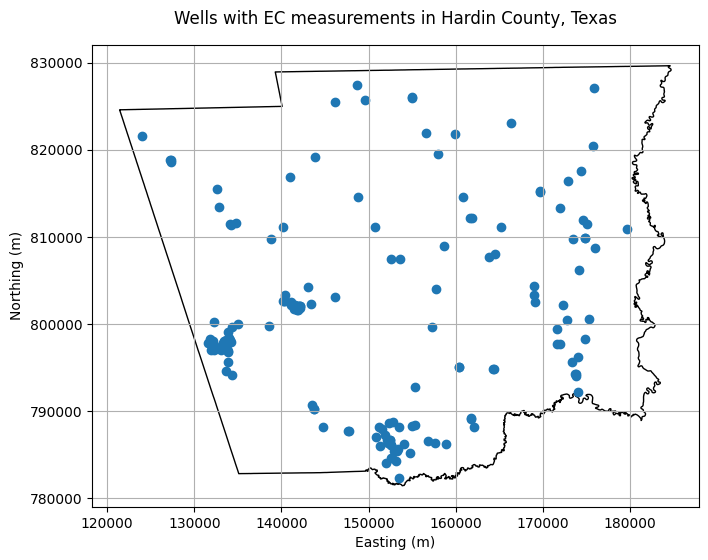

In [22]:
fig,ax =plt.subplots(figsize = (8,6))
Hardin = gpd.read_file(bndfile)
HardAEA = Hardin.to_crs('EPSG:5070')
HardAEA.plot(ax=ax, facecolor ='none', edgecolor = 'black')
ECAEA.plot(ax = ax)
plt.grid()
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Wells with EC measurements in Hardin County, Texas', pad = 15)
plt.show()

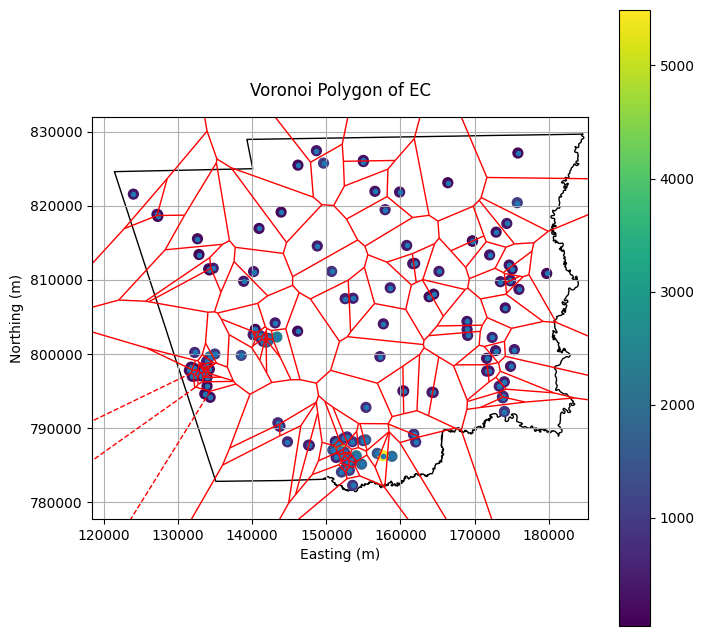

In [23]:
seedpts = np.column_stack((ECAEA.geometry.x,ECAEA.geometry.y))
vor = Voronoi(seedpts)

fig,ax =plt.subplots(figsize = (8,8))
HardAEA.plot(ax=ax, facecolor ='none', edgecolor = 'black')
voronoi_plot_2d(vor, ax=ax, show_vertices = False, line_colors = 'red')
points_plot = ECAEA.plot(ax =ax, column = 'EC', cmap ='viridis', legend =True, markersize =50)
plt.grid()
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Voronoi Polygon of EC', pad = 15)
plt.show()

In [24]:
import scipy
print(scipy.__version__)

1.15.3


In [25]:
HardAEA.to_file("HardAEA.gpkg", driver="GPKG")

In [26]:
ECAEA.to_file("ECAEA.gpkg", driver="GPKG")

In [27]:
HardAEA.to_file("AEA_output.gpkg", layer="HardAEA", driver="GPKG")
ECAEA.to_file("AEA_output.gpkg", layer="ECAEA", driver="GPKG")

**CKD Tree**

**WORK FLOW**
1. Read cty file
2. Get bounding coordinates (x-min, y-min, x-max, y-max)
3. Create Grid coordinates (np.linspace(xmin,xmax,N),(np.linspace(ymin,ymax,N))
4. Create a grid (Grd = np.meshgrid)
5. Flatten 'Grd' = Do a column stack
6. Read your pts file
7. Compute xn, yn
8. Create an array
9. Loop through xg, yg
    - Compute -- Distance CKD tree
    - Compute wt [1/(d^2 + error)]
    - Compute wt.avg
    - Append to xg, yg
    - Plot

In [28]:
Cty = gpd.read_file('HardAEA.gpkg')

In [29]:
CtyAEA = Cty.to_crs('EPSG:5070')
CtyAEA

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry
0,100,100,48199,101,20,Hardin,101,20,69,"MULTIPOLYGON (((184644.803 829662.268, 184649...."


In [30]:
xmin, ymin, xmax, ymax = CtyAEA.total_bounds
print(f"xmin: {xmin}, ymin: {ymin}, xmax: {xmax}, ymax: {ymax}")

xmin: 121419.77814283545, ymin: 781437.4566151138, xmax: 184741.03415016804, ymax: 829664.2786253961


In [31]:
#Create grid coordinates
N = 200
xg = np.linspace(xmin, xmax, N)
yg = np.linspace(ymin, ymax, N)

In [32]:
#Mesh grid
Xg, Yg = np.meshgrid(xg, yg)

In [33]:
#Create a flatten grid using column stack
gridflat = np.column_stack([Xg.ravel(), Yg.ravel()])
gridflat

array([[121419.77814284, 781437.45661511],
       [121737.9754092 , 781437.45661511],
       [122056.17267557, 781437.45661511],
       ...,
       [184104.63961743, 829664.2786254 ],
       [184422.8368838 , 829664.2786254 ],
       [184741.03415017, 829664.2786254 ]])

In [34]:
#Read the EC points
ECpts = gpd.read_file('ECAEA.gpkg')
ECptsAEA = ECpts.to_crs('EPSG:5070')
ECptsAEA

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,geometry
0,6129803,94.0,353.60,30.511945,-94.447778,POINT (148672.383 827432.266)
1,6131901,94.0,104.00,30.504723,-94.164167,POINT (175849.127 827114.308)
2,6135205,94.0,324.00,30.462501,-94.706389,POINT (123978.977 821569.177)
3,6135501,94.0,384.00,30.437500,-94.673611,POINT (127158.961 818835.617)
4,6135502,94.0,265.50,30.437222,-94.672500,POINT (127265.895 818806.227)
...,...,...,...,...,...,...
156,6155502,94.0,872.00,30.191111,-94.190000,POINT (174038.265 792244.529)
157,6155513,94.0,559.75,30.207778,-94.191945,POINT (173816.067 794091.015)
158,6161201,94.0,956.00,30.121111,-94.420000,POINT (152054.28 784080.463)
159,6161305,94.0,840.00,30.104723,-94.404723,POINT (153554.887 782286.211)


In [35]:
xn = ECptsAEA.geometry.x
yn = ECptsAEA.geometry.y

In [36]:
#Create an array of EC points
ECpts = np.column_stack([xn, yn])
ECpts

array([[148672.38321995, 827432.26619975],
       [175849.12727114, 827114.30765447],
       [123978.97688335, 821569.17685694],
       [127158.96067532, 818835.61692341],
       [127265.89502263, 818806.22747127],
       [127269.34261282, 818559.43709995],
       [140931.4889529 , 816939.90717029],
       [132628.34743738, 815549.8470271 ],
       [132830.89053976, 813424.12193548],
       [146175.77360134, 825478.21599989],
       [149631.3713256 , 825750.46176437],
       [155001.55913478, 826118.08825719],
       [155004.18627821, 825963.80328689],
       [143907.01407159, 819146.55189199],
       [148788.85556011, 814577.13866711],
       [156563.64022464, 821947.51496445],
       [159893.73018503, 821851.16594751],
       [166394.58040967, 823109.42880985],
       [157937.84559207, 819471.54648527],
       [160846.36193914, 814646.79379145],
       [174354.33067563, 817610.74597927],
       [175765.5038787 , 820415.35845258],
       [169736.77933786, 815209.16373102],
       [169

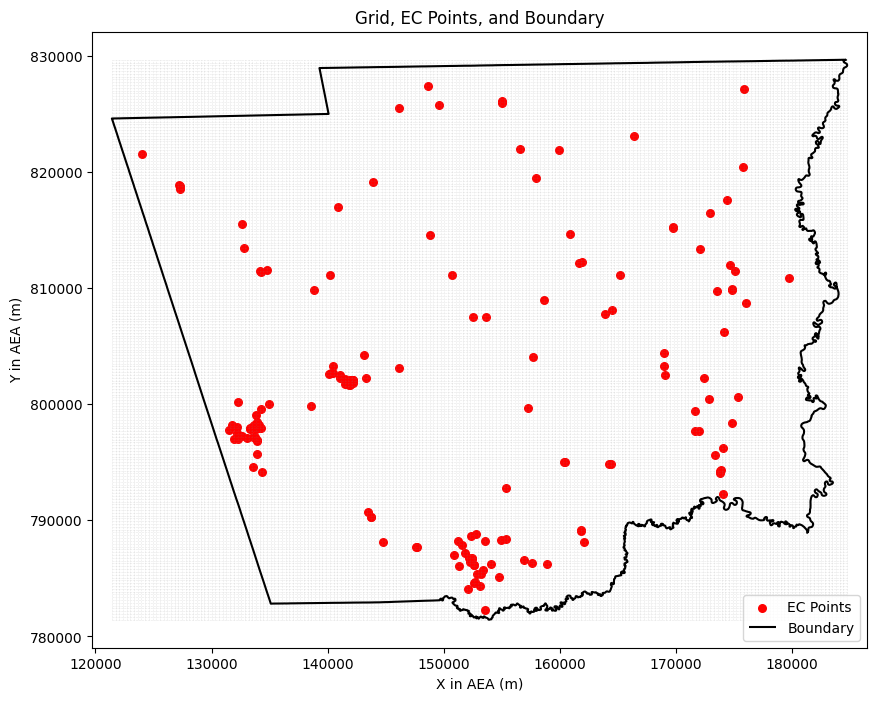

In [37]:
plt.figure(figsize=(10, 8))

plt.scatter(ECpts[:,0], ECpts[:,1], color='red', s=30, label='EC Points')

for x in xg:
    plt.plot([x, x], [ymin, ymax], color='grey', linestyle='--', linewidth=0.4, alpha = 0.2)

for y in yg:
    plt.plot([xmin, xmax], [y, y], color='grey', linestyle='--', linewidth=0.4, alpha = 0.2)

CtyAEA.boundary.plot(ax=plt.gca(), color='black', linewidth=1.5, label='Boundary')

plt.xlabel('X in AEA (m)')
plt.ylabel('Y in AEA (m)')
plt.title('Grid, EC Points, and Boundary')
plt.axis('equal')
plt.legend(loc='lower right')
plt.show()

In [38]:
from scipy.spatial import cKDTree

tree = cKDTree(ECpts)

In [39]:
k = 40 # number of nearest points
d, indices = tree.query(gridflat, k=k)

error = 1e-10

wt = 1 / (d**2 + error)
wt /= wt.sum(axis=1)[:, None]

z = ECptsAEA['EC'].values 

z_grid = np.sum(wt * z[indices], axis=1)

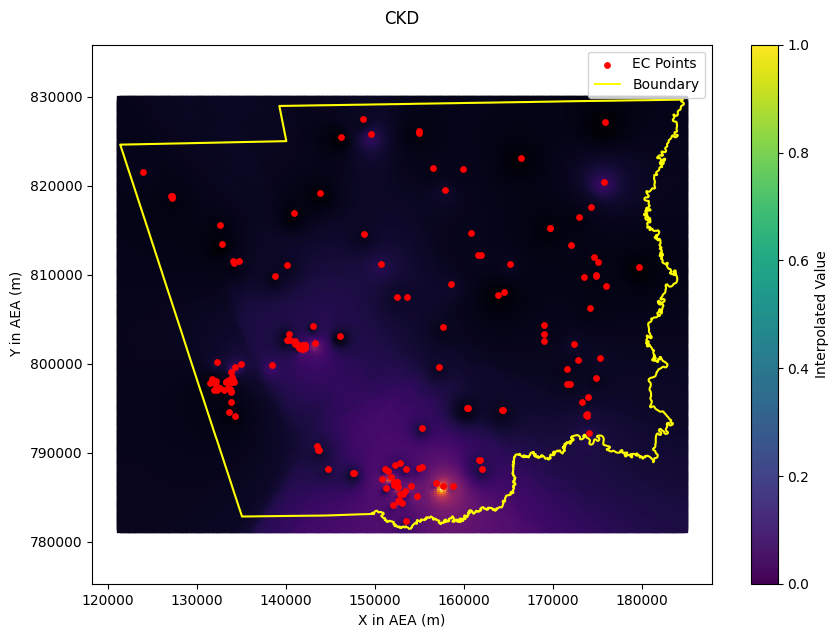

In [41]:
plt.figure(figsize=(10, 7))

# Plot interpolated grid as colored squares
plt.scatter(gridflat[:,0], gridflat[:,1], c=z_grid, s=20, cmap='inferno', marker='s')

plt.scatter(xn, yn, color='red', s=15, label='EC Points')

CtyAEA.boundary.plot(ax=plt.gca(), color='yellow', linewidth=1.5, label='Boundary')

plt.xlabel('X in AEA (m)')
plt.ylabel('Y in AEA (m)')
plt.title('CKD', pad = 15)
plt.axis('equal')
plt.colorbar(label='Interpolated Value')
plt.legend(loc='upper right')
north_arrow(ax=ax, location="lower right", rotation={"degrees":0})
plt.show()

In [53]:
k = 15  # number of nearest neighbors
epsilon = 1e-10

tree = cKDTree(ECpts) 

distances, indices = tree.query(gridflat, k=k)

# Compute weights
wt = 1 / (distances**2 + epsilon)  
z = ECptsAEA['EC'].values
z_grid = np.sum(z[indices] * wt, axis=1) / np.sum(wt,axis=1)

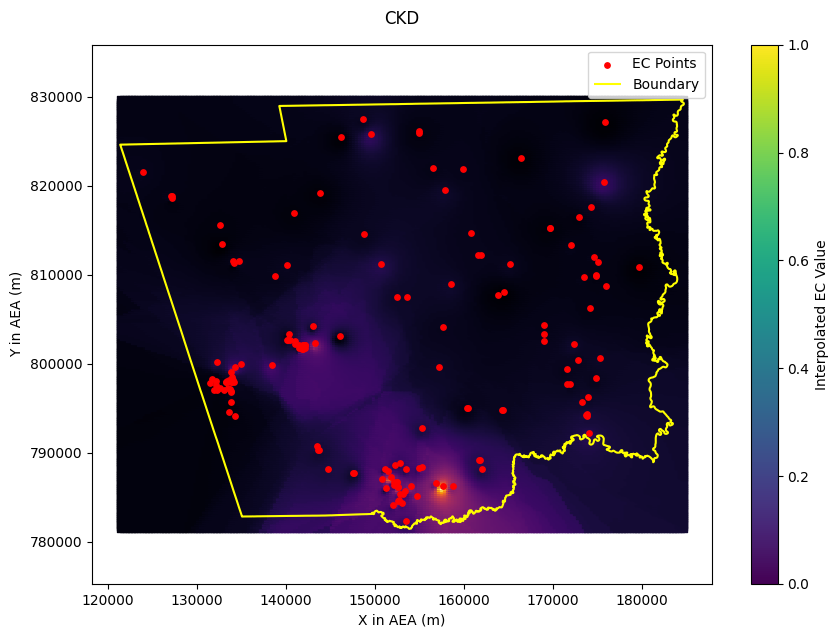

In [55]:
plt.figure(figsize=(10, 7))

# Plot interpolated grid as colored squares
plt.scatter(gridflat[:,0], gridflat[:,1], c=z_grid, s=20, cmap='inferno', marker='s')

plt.scatter(xn, yn, color='red', s=15, label='EC Points')

CtyAEA.boundary.plot(ax=plt.gca(), color='yellow', linewidth=1.5, label='Boundary')

plt.xlabel('X in AEA (m)')
plt.ylabel('Y in AEA (m)')
plt.title('CKD', pad = 15)
plt.axis('equal')
plt.colorbar(label='Interpolated EC Value')
plt.legend(loc='upper right')
north_arrow(ax=ax, location="lower right", rotation={"degrees":0})
plt.show()